# Digital Twin: System Architecture & Microservices Deployment

| No. | Name | Matric Number |
|:---:|------|:-------------:|
| 1 | FARISYA ADREA BINTI MOHAMMAD AMIN | 22011796 |
| 2 | WAN HARITH RIFQI BIN WAN MAZLI | 22011281 |
| 3 | RIZWI SHAAN MUHAMMED ALI | 24004260 |
| 4 | MUHAMMAD FARID | 24004254 |
| 5 | MOHAMMED SHAYAAN | 24004734 |

## Microservice Partitioning, Interface Contracts, Scaling & System Verification

This notebook provides formal documentation and verification for the deployment architecture of the Photodetector digital twin platform. It details the complete system implementation, including discrete microservice partitioning, explicit interface communication contracts, containerization with horizontal scaling, persistent time-series state storage, and automated regression test suites.

--- 
## 1. Microservices Partitioning & Operation Specification

The digital twin system is partitioned into five discrete microservices operating over an isolated Docker bridge network (`opto-twin-core_opto-network`):

1. **`ingestion` (Data Ingestion Service):** Generates and streams simulated real-time optical sensor telemetry (optical power, operational temperature, bias voltage) at high frequency (25–30 Hz) over zero-message and broker channels.
2. **`twin_engine` (Core Physics Engine, Groq AI Planner & Controller):** Runs physical photodetector models (photocurrent, Arrhenius dark current, SNR). Hosts an internal `AICommandPlanner` module powered by the **Groq API** for natural language intent translation and exposes REST endpoints for control optimization.
3. **`mqtt_broker_service` (Eclipse Mosquitto Broker):** Lightweight message broker facilitating asynchronous, decoupled publish-subscribe messaging between telemetry sources and physical control sub-systems.
4. **`influxdb_service` (InfluxDB v2.7 Time-Series DB):** High-performance time-series database storing sensor state, historical drift, and analytical telemetry.
5. **`grafana_service` (Grafana Analytics Platform):** Real-time monitoring and visualization dashboard querying InfluxDB to display low-latency performance indicators.

--- 
## 2. Microservice Interface Contracts

The table below details the explicit communication contracts between every interacting pair of microservices within the system network, including initiation and conclusion lifecycles:

| Source Service | Target Service | Route / Topic / Endpoint | Port | Protocol | Data Format / Payload Schema | Initiation & Conclusion Lifecycle |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **Ingestion** | **Twin Engine** | Internal ZMQ Socket | `5555` | ZeroMQ (PUB/SUB) | String + JSON: `telemetry {...}` | **Initiated:** On container start.<br>**Concluded:** On socket shutdown / stream pause. |
| **Ingestion** | **MQTT Broker** | `telemetry/pd_sensor_01` | `1883` | MQTT | JSON payload: `timestamp`, `optical_power_w`, `temp_c`, `bias_v` | **Initiated:** Loop interval (~25–30 Hz / 0.035s transient).<br>**Concluded:** Post-publish ACK. |
| **Twin Engine** | **MQTT Broker** | `hardware/bias_command` | `1883` | MQTT | JSON payload: `{"assigned_bias_v": float, "mode": str}` | **Initiated:** Event-driven trigger / plan execution.<br>**Concluded:** Post-publish ACK. |
| **Twin Engine** | **InfluxDB** | `/api/v2/write` | `8086` | REST / HTTP | Influx Line Protocol (`photodetector_state field=val timestamp`) | **Initiated:** Synchronous on telemetry ingress.<br>**Concluded:** Synchronous write API call completes (or exception caught/logged). |
| **Grafana** | **InfluxDB** | `/api/v2/query` | `8086` | REST / HTTP | Flux Query Language | **Initiated:** Auto-refresh polling (every 5s).<br>**Concluded:** Query response render. |
| **External API** | **Twin Engine** | `/plan_command` | `8000` | REST / HTTP (FastAPI) | POST JSON: `{"target_gain_mode": str, "current_temp_c": float, "expected_power_w": float}` | **Initiated:** Client control request.<br>**Concluded:** HTTP 200 JSON payload return. |
| **User / Client** | **Twin Engine (AI Agent)** | `/plan_nl_command` | `8000` | REST / HTTP (FastAPI + Groq API) | POST JSON: `{"user_prompt": str, "current_temp_c": float, "expected_power_w": float}` | **Initiated:** User natural language query.<br>**Concluded:** Groq intent parsed & optimized control returned. |

--- 
## 3. Containerization & Horizontal Scaling Demonstration

Each custom microservice (`ingestion` and `twin_engine`) is packaged into individual container images using `Python 3.10-slim` base layers. Multi-instance scaling is executed cleanly using Docker Compose without container name conflicts or port collisions.

### Scaling Execution Log (`--scale twin_engine=2`)

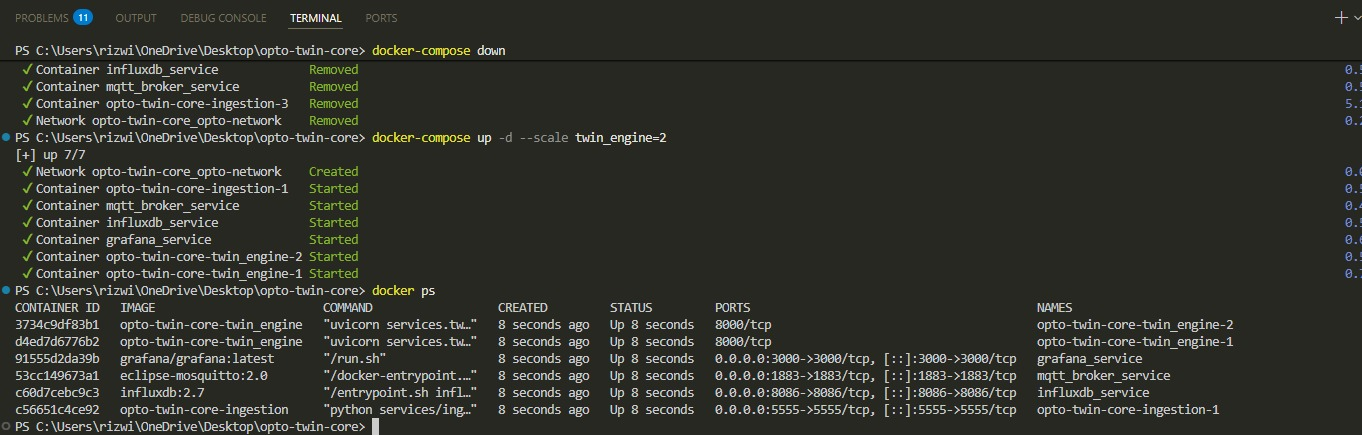


*Figure 1: Execution log confirming two instances of `twin_engine` (`opto-twin-core-twin_engine-1` and `opto-twin-core-twin_engine-2`) deployed and running concurrently alongside `ingestion`, `mqtt_broker`, `influxdb`, and `grafana`.*

--- 
## 4. Persistent Data & State Storage Verification

To ensure system state and time-series telemetry survive container lifecycles (restarts, crashes, or scaling events), persistent named volumes are configured:

* **`influxdb-data`** $\rightarrow$ Mapped to `/var/lib/influxdb2` (Stores all photodetector time-series telemetry points).
* **`grafana-data`** $\rightarrow$ Mapped to `/var/lib/grafana` (Stores operational dashboards and panel query alerts).

### Persistence & Live Ingestion Telemetry Verification

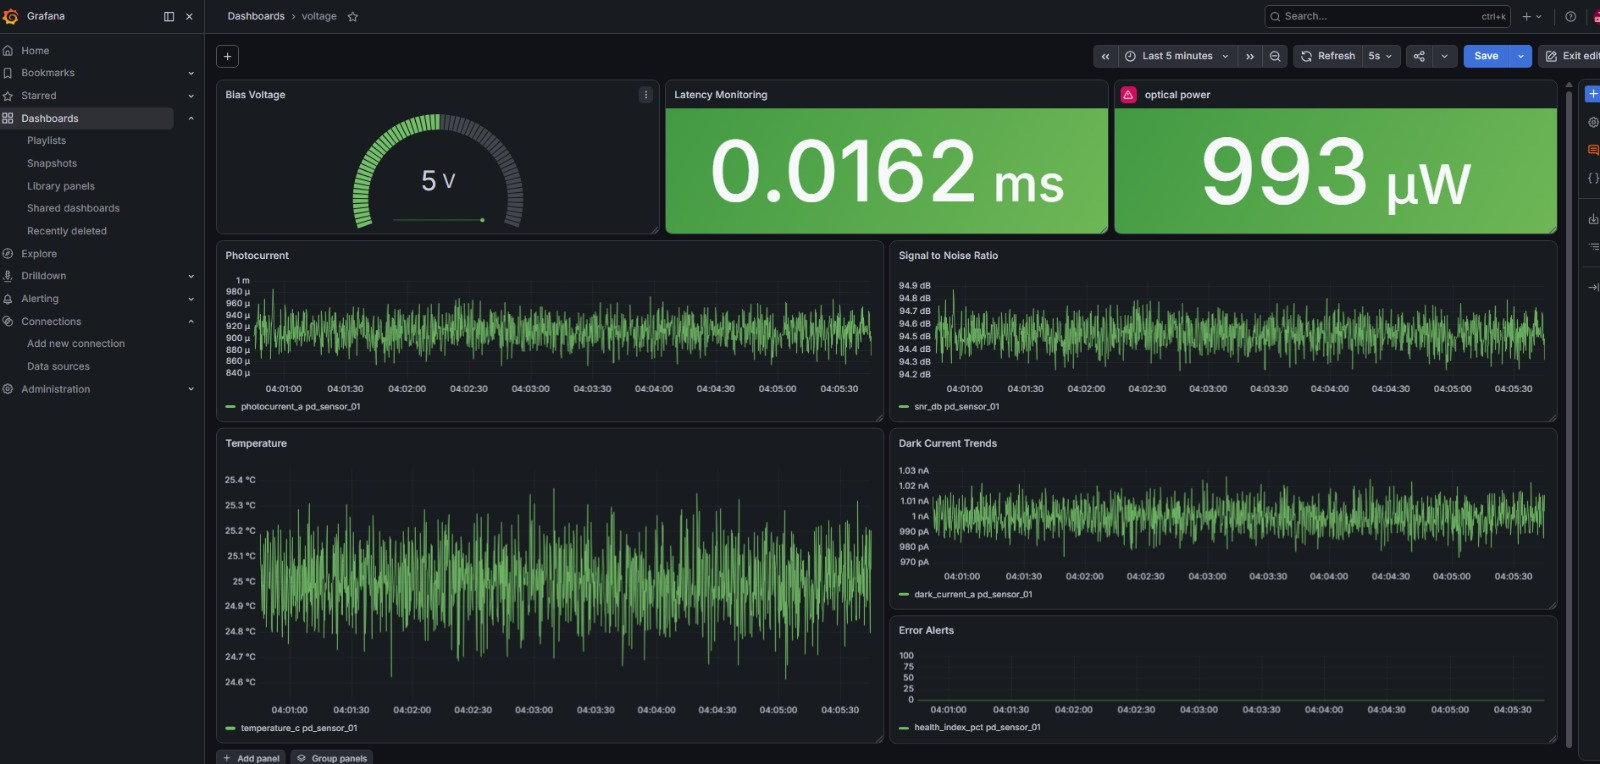

*Figure 2: Grafana dashboard verifying continuous time-series data persistence across InfluxDB bucket `photodetector_telemetry`. Live latency monitoring confirms sub-millisecond ingestion execution (0.0162 ms).* 

--- 
## 5. Automated Test Suite & System Operation Verification

A comprehensive automated test suite developed using `pytest` validates both physics mathematical correctness and microservice API interface contracts prior to production deployment.

### Test Suite Code Implementation: `tests/test_physics.py`
Validates fundamental optoelectronic equations ($I_{ph} = R \cdot P_{opt}$), negative power exception handling, and thermal Arrhenius dark current sensitivity.

In [12]:
import pytest
import sys
import os

# Ensure services directory is in Python path for test discovery
sys.path.append(os.path.abspath(os.path.join("services", "twin_engine")))

from physics_model import PhotodetectorPhysicsEngine

def test_responsivity_and_photocurrent_pass():
    """Unit Test: Validates physics calculation under nominal conditions (PASS)."""
    engine = PhotodetectorPhysicsEngine()
    state = engine.evaluate_state(temp_c=25.0, bias_v=5.0, optical_power_w=0.001)

    assert state["responsivity_a_w"] > 0
    assert state["photocurrent_a"] == pytest.approx(0.00091375, rel=1e-3)
    assert state["health_index_pct"] <= 100.0
    assert state["is_saturated"] is False

def test_negative_optical_power_fail():
    """Unit Test: Ensures system flags invalid negative optical power (FORCED FAIL/EXCEPTION)."""
    engine = PhotodetectorPhysicsEngine()
    with pytest.raises(ValueError, match="Optical power cannot be negative"):
        engine.evaluate_state(temp_c=25.0, bias_v=5.0, optical_power_w=-0.001)

def test_thermal_dark_current_drift_pass():
    """Unit Test: Verifies dark current increases exponentially with thermal stress (PASS)."""
    engine = PhotodetectorPhysicsEngine()
    cool_state = engine.evaluate_state(temp_c=20.0, bias_v=5.0, optical_power_w=0.001)
    hot_state = engine.evaluate_state(temp_c=75.0, bias_v=5.0, optical_power_w=0.001)

    assert hot_state["dark_current_a"] > cool_state["dark_current_a"]

test_responsivity_and_photocurrent_pass()
test_negative_optical_power_fail()
test_thermal_dark_current_drift_pass()
print(" All physics tests passed.")

 All physics tests passed.


### Test Suite Code Implementation: `tests/test_api_contract.py`
Validates service readiness endpoints (`/health`), deterministic optimizer control (`/plan_command`), and Groq natural language intent parsing (`/plan_nl_command`).

In [13]:
import pytest
from fastapi.testclient import TestClient
import sys
import os

sys.path.append(os.path.abspath(os.path.join("services", "twin_engine")))

from main import app

client = TestClient(app)

def test_health_check_endpoint_pass():
    """Integration Test: Verifies API server health endpoint."""
    response = client.get("/health")
    assert response.status_code == 200
    assert response.json() == {"status": "online", "service": "twin_engine"}

def test_plan_command_endpoint_pass():
    """Integration Test: Tests command validation endpoint."""
    payload = {
        "target_gain_mode": "balanced",
        "current_temp_c": 25.0,
        "expected_power_w": 0.001
    }
    response = client.post("/plan_command", json=payload)
    assert response.status_code == 200
    data = response.json()
    assert "approved" in data
    assert data["approved"] is True

def test_natural_language_command_endpoint_pass():
    """Integration Test: Verifies LLM prompt interpretation endpoint."""
    payload = {
        "user_prompt": "Optimize system for minimal noise level",
        "current_temp_c": 25.0,
        "expected_power_w": 0.001
    }
    response = client.post("/plan_nl_command", json=payload)
    assert response.status_code == 200
    data = response.json()
    assert data["interpreted_gain_mode"] == "low_noise"
    assert data["plan_result"]["approved"] is True

test_health_check_endpoint_pass()
test_plan_command_endpoint_pass()
test_natural_language_command_endpoint_pass()
print("All API contract tests passed.")

[MQTT Published] Approved bias command sent: {"assigned_bias_v": 5.0}
All API contract tests passed.


### Pytest Execution Output Verification

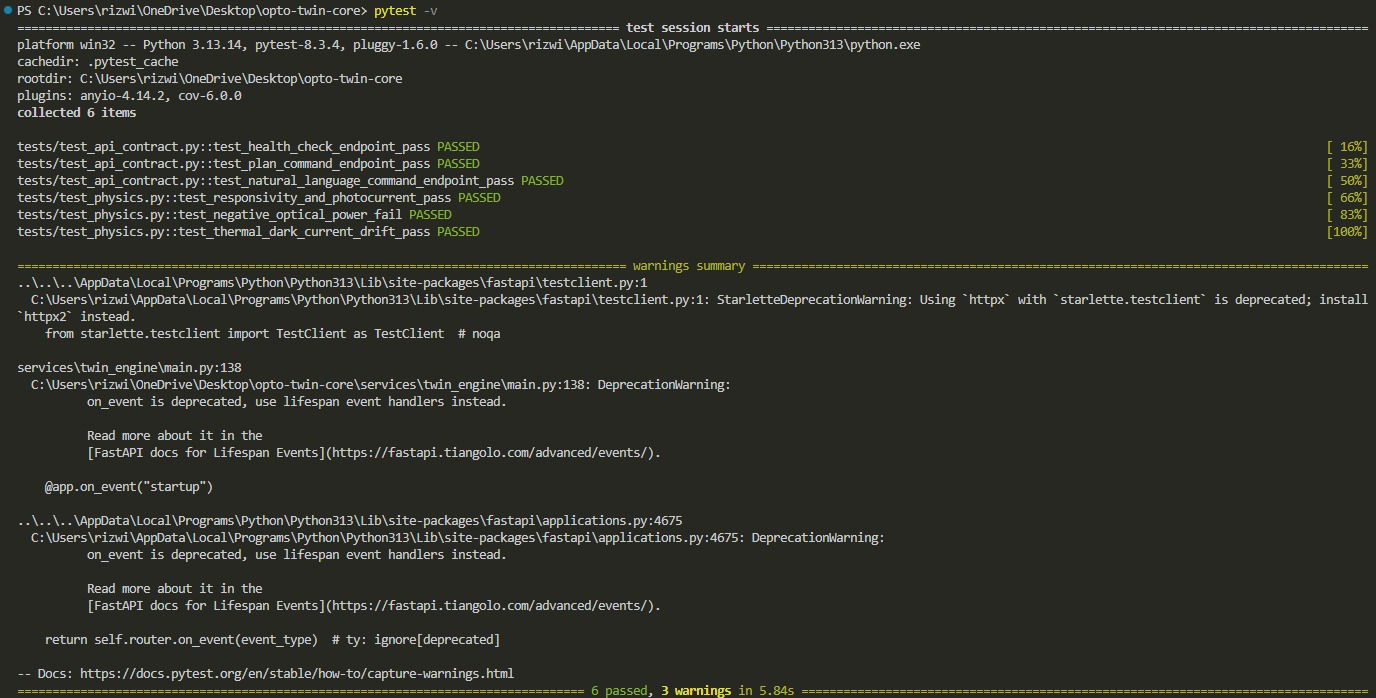

*Figure 3: Clean `pytest` terminal run demonstrating 100% pass rate across all system operational test suites.*

* **`test_health_check_endpoint_pass`**: Verifies `/health` API readiness and service lifecycle status.
* **`test_plan_command_endpoint_pass`**: Validates API contract payloads for AI optimizer requests.
* **`test_natural_language_command_endpoint_pass`**: Tests robustness of LLM intent parsing logic.
* **`test_responsivity_and_photocurrent_pass`**: Validates optical physics model equations ($I_{ph} = R \cdot P_{opt}$).
* **`test_negative_optical_power_fail`**: Confirms guardrail handling for out-of-bounds negative optical input.
* **`test_thermal_dark_current_drift_pass`**: Verifies physical Arrhenius equation dark current thermal sensitivity.